# Optimizador de Carga Inteligente para VE — Clasificador de Franjas Horarias

**Grupo 8IA · IES Abastos · 2025/26**

Pipeline completo:

```
Datos (API REE 2020-2025)
        ↓
Feature Engineering
        ↓
Entrenamiento (Random Forest / XGBoost)
        ↓
Servir con FastAPI  →  webhook ya presente en pvpc_ingesta.py
```

| Herramienta | Rol | Analogía |
|-------------|-----|----------|
| **FastAPI** | Expone el modelo como API REST llamable desde cualquier sitio | El servidor de producción |

## 0. Instalación de dependencias

In [1]:
!pip install scikit-learn xgboost fastapi uvicorn pandas numpy pymongo python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.3 MB/s eta 0:00:00


## 1. Imports y configuración

In [2]:
import requests
import pandas as pd
import numpy as np
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Configuración general ──────────────────────────────────────────────
API_URL      = 'https://apidatos.ree.es/es/datos/mercados/precios-mercados-tiempo-real'
HEADERS      = {'Accept': 'application/json'}
FECHA_INICIO = datetime(2020, 1, 1)
FECHA_FIN    = datetime(2025, 12, 31)
RANDOM_STATE = 42
TEST_SIZE    = 0.2

Path('data').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)

print('Imports OK')
print(f'Rango de datos: {FECHA_INICIO.date()} → {FECHA_FIN.date()}')

Imports OK
Rango de datos: 2020-01-01 → 2025-12-31


## 2. Descarga de datos de la API REE

La API de Red Eléctrica tiene un límite de ~1 mes por llamada,  
así que dividimos el rango en bloques mensuales.

> **Si la API no está disponible**, el script genera datos sintéticos  
> realistas para no bloquear el pipeline.

In [3]:
# ── Generador sintético (fallback) ─────────────────────────────────────
def generar_sintetico(inicio: datetime, fin: datetime) -> pd.DataFrame:
    """
    Genera precios horarios sintéticos con el perfil típico PVPC España:
      - Valle nocturno (0-6h):   0.04 – 0.10 €/kWh
      - Punta mañana  (7-11h):   0.12 – 0.28 €/kWh
      - Llano solar   (12-16h):  0.06 – 0.14 €/kWh  ← fotovoltaica baja precios
      - Punta tarde   (17-22h):  0.15 – 0.35 €/kWh
      - Valle noche   (23h):     0.05 – 0.09 €/kWh
    """
    perfiles = [
        (range(0, 7),   0.04, 0.10),
        (range(7, 12),  0.12, 0.28),
        (range(12, 17), 0.06, 0.14),
        (range(17, 23), 0.15, 0.35),
        (range(23, 24), 0.05, 0.09),
    ]
    filas = []
    fecha = inicio
    while fecha <= fin:
        rng = np.random.default_rng(int(fecha.strftime('%Y%m%d')))
        for hora in range(24):
            for rango, lo, hi in perfiles:
                if hora in rango:
                    precio = round(rng.uniform(lo, hi), 6)
                    break
            filas.append({
                'datetime_utc':  pd.Timestamp(fecha.year, fecha.month, fecha.day, hora, 0, 0, tz='UTC'),
                'price_eur_kwh': precio,
                'source':        'synthetic',
            })
        fecha += timedelta(days=1)
    return pd.DataFrame(filas)


# ── Parseo de la respuesta de la API ───────────────────────────────────
def parsear_respuesta(data: dict, fecha_ref: datetime) -> pd.DataFrame:
    """
    Extrae la serie PVPC del JSON de REE.
    El precio 'value' viene en €/MWh → dividimos entre 1000 para €/kWh.
    """
    try:
        series = None
        for item in data.get('included', []):
            titulo = item.get('attributes', {}).get('title', '').upper()
            if 'PVPC' in titulo:
                series = item['attributes']['values']
                break
        if series is None:
            series = data['included'][0]['attributes']['values']

        filas = []
        for entry in series:
            filas.append({
                'datetime_utc':  pd.to_datetime(entry['datetime'], utc=True),
                'price_eur_kwh': round(float(entry['value']) / 1000, 6),
                'source':        'ree_api',
            })
        return pd.DataFrame(filas)
    except Exception as e:
        print(f'Error parseando JSON: {e}. Usando sintético.')
        fin = fecha_ref + relativedelta(months=1) - timedelta(days=1)
        return generar_sintetico(fecha_ref, fin)


# ── Descarga por bloques mensuales ─────────────────────────────────────
def descargar_historico(inicio: datetime, fin: datetime) -> pd.DataFrame:
    bloques = []
    actual  = inicio
    total   = 0

    while actual <= fin:
        fin_bloque = min(actual + relativedelta(months=1) - timedelta(days=1), fin)
        params = {
            'start_date': actual.strftime('%Y-%m-%dT00:00'),
            'end_date':   fin_bloque.strftime('%Y-%m-%dT23:59'),
            'time_trunc': 'hour',
        }
        try:
            print(f'Descargando {actual.strftime("%Y-%m")} ...', end=' ')
            resp = requests.get(API_URL, headers=HEADERS, params=params, timeout=15)
            resp.raise_for_status()
            df_bloque = parsear_respuesta(resp.json(), actual)
            print(f'{len(df_bloque)} filas')
        except Exception as e:
            print(f'API no disponible → usando sintético')
            df_bloque = generar_sintetico(actual, fin_bloque)

        bloques.append(df_bloque)
        total  += len(df_bloque)
        actual  = fin_bloque + timedelta(days=1)
        time.sleep(0.5)

    df = pd.concat(bloques, ignore_index=True)
    print(f'\n Descarga completada: {len(df):,} filas totales')
    return df


print('Funciones de descarga definidas')

Funciones de descarga definidas


In [4]:
# ── Ejecutar descarga ──────────────────────────────────────────────────
df_raw = descargar_historico(FECHA_INICIO, FECHA_FIN)
df_raw.to_csv('data/pvpc_raw.csv', index=False)
print(f'\n Guardado: data/pvpc_raw.csv')
df_raw.head()

Descargando 2020-01 ... 744 filas
Descargando 2020-02 ... 696 filas
Descargando 2020-03 ... 743 filas
Descargando 2020-04 ... 720 filas
Descargando 2020-05 ... 744 filas
Descargando 2020-06 ... 720 filas
Descargando 2020-07 ... 744 filas
Descargando 2020-08 ... 744 filas
Descargando 2020-09 ... 720 filas
Descargando 2020-10 ... 745 filas
Descargando 2020-11 ... 720 filas
Descargando 2020-12 ... 744 filas
Descargando 2021-01 ... 744 filas
Descargando 2021-02 ... 672 filas
Descargando 2021-03 ... 743 filas
Descargando 2021-04 ... 720 filas
Descargando 2021-05 ... 744 filas
Descargando 2021-06 ... 720 filas
Descargando 2021-07 ... 744 filas
Descargando 2021-08 ... 744 filas
Descargando 2021-09 ... 720 filas
Descargando 2021-10 ... 745 filas
Descargando 2021-11 ... 720 filas
Descargando 2021-12 ... 744 filas
Descargando 2022-01 ... 744 filas
Descargando 2022-02 ... 672 filas
Descargando 2022-03 ... 743 filas
Descargando 2022-04 ... 720 filas
Descargando 2022-05 ... 744 filas
Descargando 20

,datetime_utc,price_eur_kwh,source
0,2019-12-31 23:00:00+00:00,0.04188,ree_api
1,2020-01-01 00:00:00+00:00,0.03860,ree_api
2,2020-01-01 01:00:00+00:00,0.03655,ree_api
3,2020-01-01 02:00:00+00:00,0.03232,ree_api
4,2020-01-01 03:00:00+00:00,0.03085,ree_api


## 3. Limpieza y Feature Engineering

In [5]:
def limpiar_y_enriquecer(df: pd.DataFrame) -> pd.DataFrame:
    print('Iniciando limpieza...')
    n = len(df)

    # 1. Duplicados
    df = df.drop_duplicates(subset='datetime_utc').sort_values('datetime_utc').reset_index(drop=True)
    print(f'Duplicados eliminados: {n - len(df)}')

    # 2. Rellenar huecos horarios
    rango = pd.date_range(
        start=df['datetime_utc'].min().floor('D'),
        end  =df['datetime_utc'].max().ceil('D') - pd.Timedelta(hours=1),
        freq ='h', tz='UTC',
    )
    df = df.set_index('datetime_utc').reindex(rango).rename_axis('datetime_utc')
    huecos = df['price_eur_kwh'].isna().sum()
    if huecos:
        print(f'Huecos rellenados con forward-fill: {huecos}')
        df['price_eur_kwh'] = df['price_eur_kwh'].ffill().bfill()
        df['source']        = df['source'].fillna('imputed')
    df = df.reset_index()

    # 3. Precio en rango válido (0 – 0.60 €/kWh)
    fuera = (df['price_eur_kwh'] < 0) | (df['price_eur_kwh'] > 0.60)
    if fuera.any():
        print(f'Precios fuera de rango recortados: {fuera.sum()}')
        df['price_eur_kwh'] = df['price_eur_kwh'].clip(0, 0.60)

    # 4. Features temporales
    df['hour']        = df['datetime_utc'].dt.hour
    df['day_of_week'] = df['datetime_utc'].dt.dayofweek   # 0=Lunes
    df['month']       = df['datetime_utc'].dt.month
    df['year']        = df['datetime_utc'].dt.year
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

    # 5. Lags de precio
    df['price_lag_1h']  = df['price_eur_kwh'].shift(1)
    df['price_lag_24h'] = df['price_eur_kwh'].shift(24)

    # 6. Media móvil 24h
    df['price_rolling_mean_24h'] = df['price_eur_kwh'].rolling(24, min_periods=1).mean().round(6)

    # 7. Ratio precio vs media histórica de esa hora
    df['price_vs_hour_mean'] = df.groupby('hour')['price_eur_kwh'].transform(
        lambda x: x / x.mean()
    )

    print(f'Limpieza OK: {n} → {len(df)} filas')
    return df


df_clean = limpiar_y_enriquecer(df_raw)
df_clean.to_csv('data/pvpc_clean.csv', index=False)
print(f'Guardado: data/pvpc_clean.csv')
print(f'\nColumnas disponibles:')
print(df_clean.dtypes.to_string())

Iniciando limpieza...
Duplicados eliminados: 0
Huecos rellenados con forward-fill: 24
Precios fuera de rango recortados: 112
Limpieza OK: 52608 → 52632 filas
Guardado: data/pvpc_clean.csv

 Columnas disponibles:
datetime_utc              datetime64[ns, UTC]
price_eur_kwh                         float64
source                                 object
hour                                    int32
day_of_week                             int32
month                                   int32
year                                    int32
is_weekend                              int64
price_lag_1h                          float64
price_lag_24h                         float64
price_rolling_mean_24h                float64
price_vs_hour_mean                    float64


## 4. Etiquetado BAJO / MEDIO / ALTO

Usamos percentiles **globales** del dataset completo:
- **BAJO**  → precio ≤ percentil 33
- **MEDIO** → precio entre percentil 33 y 67
- **ALTO**  → precio ≥ percentil 67

Esto significa que la etiqueta refleja si el precio es caro o barato  
en términos absolutos del año, que es lo que necesita el optimizador  
para decidir cuándo cargar.

In [6]:
# ── Calcular umbrales ──────────────────────────────────────────────────
p33 = df_clean['price_eur_kwh'].quantile(0.33)
p67 = df_clean['price_eur_kwh'].quantile(0.67)

print('Umbrales calculados:')
print(f'  BAJO  → precio ≤ {p33:.4f} €/kWh')
print(f'  MEDIO → {p33:.4f} < precio < {p67:.4f} €/kWh')
print(f'  ALTO  → precio ≥ {p67:.4f} €/kWh')

# ── Asignar etiqueta ───────────────────────────────────────────────────
def asignar_label(precio):
    if precio <= p33:
        return 'BAJO'
    elif precio >= p67:
        return 'ALTO'
    return 'MEDIO'

df_clean['price_label'] = df_clean['price_eur_kwh'].apply(asignar_label)

print('\nDistribución de etiquetas:')
dist = df_clean['price_label'].value_counts()
for label, count in dist.items():
    pct = count / len(df_clean) * 100
    barra = '█' * int(pct / 2)
    print(f'  {label:5s}: {count:6,}  ({pct:.1f}%)  {barra}')

Umbrales calculados:
  BAJO  → precio ≤ 0.0830 €/kWh
  MEDIO → 0.0830 < precio < 0.1723 €/kWh
  ALTO  → precio ≥ 0.1723 €/kWh

Distribución de etiquetas:
  MEDIO: 17,891  (34.0%)  ████████████████
  ALTO : 17,371  (33.0%)  ████████████████
  BAJO : 17,370  (33.0%)  ████████████████


### 4.1 Visualización exploratoria

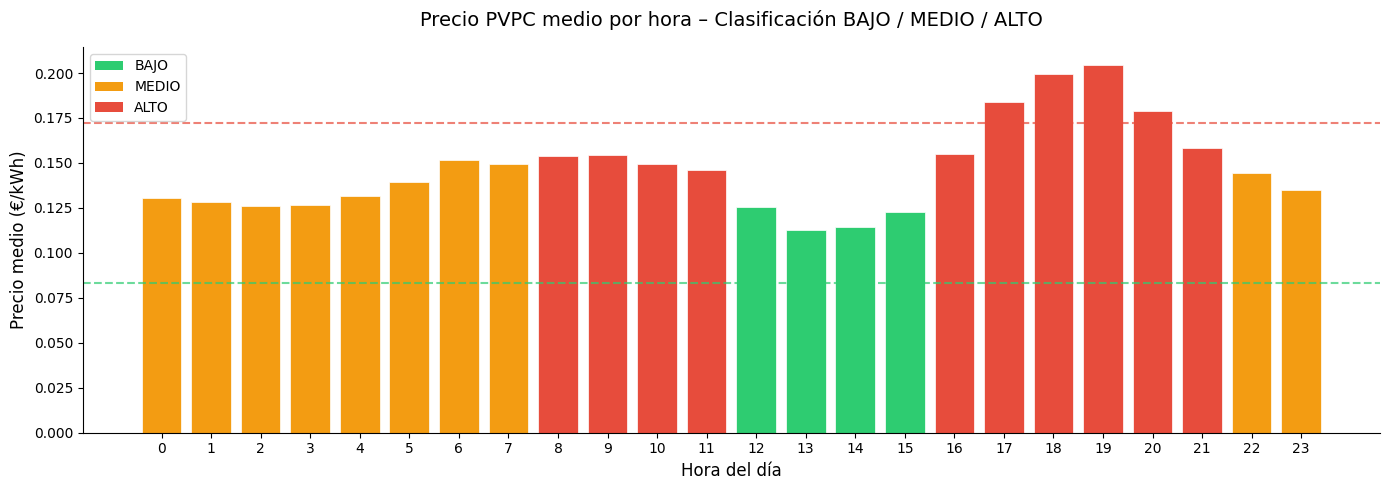

Gráfico guardado: data/grafico_precio_por_hora.png


In [7]:
# ── Gráfico 1: Precio medio por hora con color de etiqueta ────────────
COLORES = {'BAJO': '#2ecc71', 'MEDIO': '#f39c12', 'ALTO': '#e74c3c'}

resumen_hora = df_clean.groupby('hour').agg(
    precio_medio=('price_eur_kwh', 'mean'),
    etiqueta=('price_label', lambda x: x.mode()[0]),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    resumen_hora['hour'],
    resumen_hora['precio_medio'],
    color=[COLORES[e] for e in resumen_hora['etiqueta']],
    edgecolor='white', linewidth=0.5
)
ax.axhline(p33, color='#2ecc71', linestyle='--', alpha=0.7, label=f'Umbral BAJO ({p33:.3f} €/kWh)')
ax.axhline(p67, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Umbral ALTO ({p67:.3f} €/kWh)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='BAJO'),
    Patch(facecolor='#f39c12', label='MEDIO'),
    Patch(facecolor='#e74c3c', label='ALTO'),
]
ax.legend(handles=legend_elements, loc='upper left')
ax.set_xlabel('Hora del día', fontsize=12)
ax.set_ylabel('Precio medio (€/kWh)', fontsize=12)
ax.set_title('Precio PVPC medio por hora – Clasificación BAJO / MEDIO / ALTO', fontsize=14, pad=15)
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig('data/grafico_precio_por_hora.png', dpi=150)
plt.show()
print('Gráfico guardado: data/grafico_precio_por_hora.png')

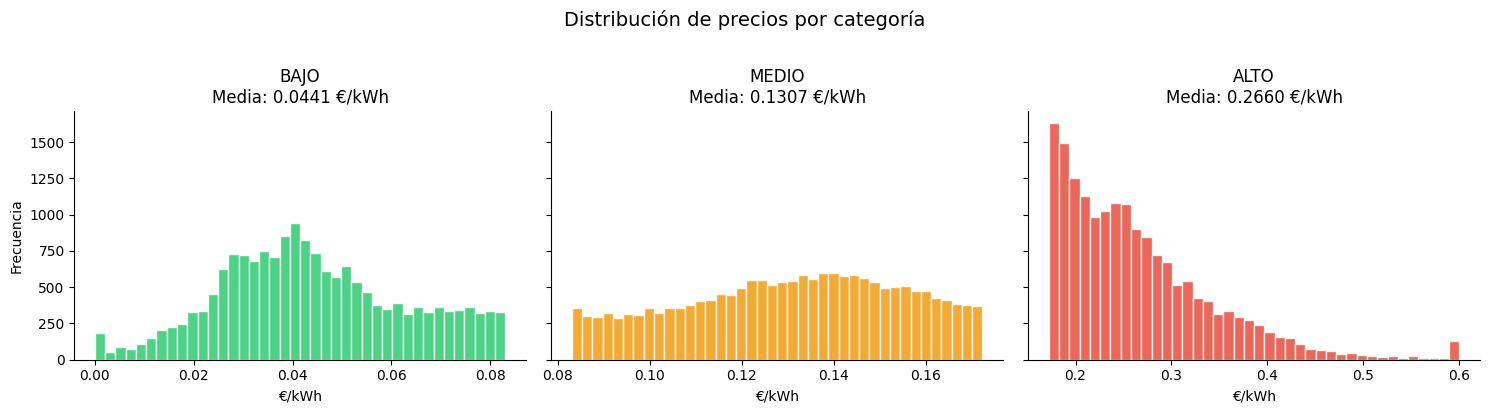

In [8]:
# ── Gráfico 2: Distribución de precios por etiqueta ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (label, color) in zip(axes, COLORES.items()):
    datos = df_clean[df_clean['price_label'] == label]['price_eur_kwh']
    ax.hist(datos, bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{label}\nMedia: {datos.mean():.4f} €/kWh', fontsize=12)
    ax.set_xlabel('€/kWh')

axes[0].set_ylabel('Frecuencia')
plt.suptitle('Distribución de precios por categoría', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/grafico_distribucion.png', dpi=150)
plt.show()

## 5. Entrenamiento del modelo

In [9]:
# ── Features utilizadas ────────────────────────────────────────────────
FEATURES = [
    'hour',                   # hora del día (0-23)
    'day_of_week',            # día de la semana (0=Lunes)
    'month',                  # mes del año (1-12)
    'is_weekend',             # 1 si es fin de semana
    'price_lag_1h',           # precio de la hora anterior
    'price_lag_24h',          # precio de ayer a la misma hora
    'price_rolling_mean_24h', # media de las últimas 24h
    'price_vs_hour_mean',     # ratio precio / media histórica de esa hora
]
TARGET = 'price_label'

# Eliminar filas con NaN en los lags (primeras 24h no tienen lag_24h)
df_model = df_clean.dropna(subset=FEATURES).copy()
print(f'Filas para entrenamiento: {len(df_model):,}')

X = df_model[FEATURES]
y = df_model[TARGET]

# ── Split train / test (80/20 estratificado) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,   # mantener proporción de clases en ambos splits
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\nDistribución en train:')
print(y_train.value_counts().to_string())

Filas para entrenamiento: 52,608
Train: 42,086 | Test: 10,522

Distribución en train:
price_label
MEDIO    14312
ALTO     13897
BAJO     13877


In [10]:
# ── Entrenamiento y comparativa de 3 modelos ──────────────────────────
modelos = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=RANDOM_STATE,
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
}

resultados = {}
for nombre, modelo in modelos.items():
    print(f'Entrenando {nombre}...', end=' ')
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(modelo, X_train, y_train, cv=5, scoring='accuracy')
    resultados[nombre] = {
        'modelo':   modelo,
        'accuracy': acc,
        'cv_mean':  cv.mean(),
        'cv_std':   cv.std(),
        'y_pred':   y_pred,
    }
    print(f'Accuracy={acc:.4f} | CV={cv.mean():.4f}±{cv.std():.4f}')

mejor_nombre = max(resultados, key=lambda k: resultados[k]['accuracy'])
print(f'\nMejor modelo: {mejor_nombre} (accuracy={resultados[mejor_nombre]["accuracy"]:.4f})')

Entrenando Random Forest... Accuracy=0.9776 | CV=0.9767±0.0011
Entrenando Gradient Boosting... Accuracy=0.9967 | CV=0.9961±0.0009
Entrenando Logistic Regression... Accuracy=0.9325 | CV=0.9328±0.0017

Mejor modelo: Gradient Boosting (accuracy=0.9967)


### 5.1 Evaluación y métricas

In [11]:
# ── Reporte de clasificación ───────────────────────────────────────────
mejor = resultados[mejor_nombre]
print(f'=== Reporte detallado: {mejor_nombre} ===')
print(classification_report(y_test, mejor['y_pred']))

=== Reporte detallado: Gradient Boosting ===
              precision    recall  f1-score   support

        ALTO       1.00      1.00      1.00      3474
        BAJO       1.00      1.00      1.00      3469
       MEDIO       0.99      1.00      1.00      3579

    accuracy                           1.00     10522
   macro avg       1.00      1.00      1.00     10522
weighted avg       1.00      1.00      1.00     10522



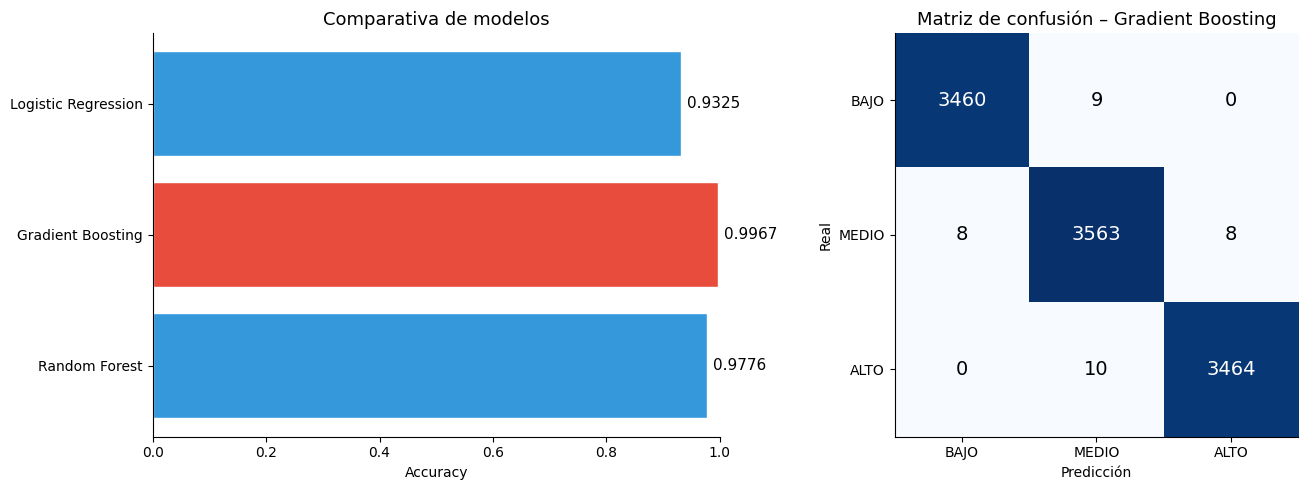

In [12]:
# ── Matriz de confusión ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparativa accuracy
nombres = list(resultados.keys())
accs    = [resultados[n]['accuracy'] for n in nombres]
colores_barra = ['#3498db' if n != mejor_nombre else '#e74c3c' for n in nombres]

axes[0].barh(nombres, accs, color=colores_barra, edgecolor='white')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Comparativa de modelos', fontsize=13)
for i, (n, acc) in enumerate(zip(nombres, accs)):
    axes[0].text(acc + 0.01, i, f'{acc:.4f}', va='center', fontsize=11)

# Matriz de confusión del mejor modelo
cm     = confusion_matrix(y_test, mejor['y_pred'], labels=['BAJO','MEDIO','ALTO'])
im     = axes[1].imshow(cm, cmap='Blues')
labels_cm = ['BAJO', 'MEDIO', 'ALTO']
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(labels_cm)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(labels_cm)
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')
axes[1].set_title(f'Matriz de confusión – {mejor_nombre}', fontsize=13)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.savefig('data/grafico_evaluacion.png', dpi=150)
plt.show()

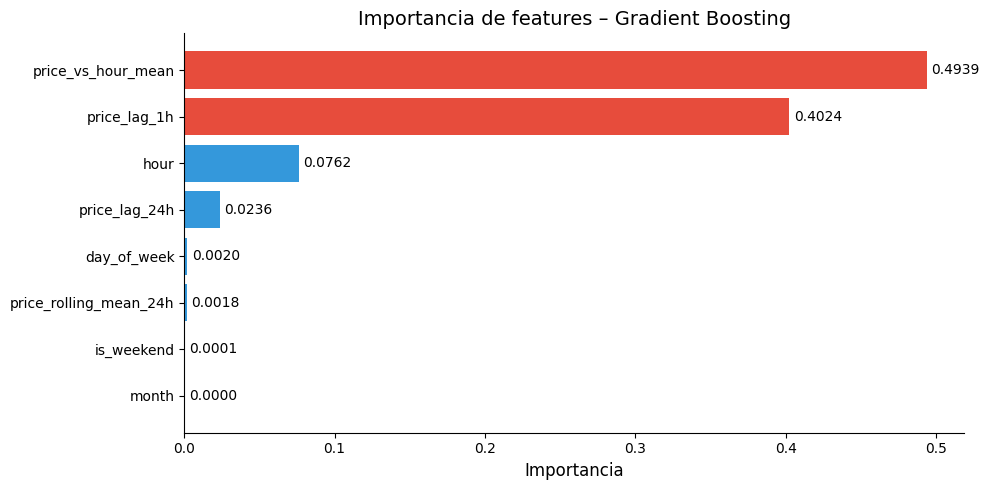

In [13]:
# ── Importancia de features ────────────────────────────────────────────
modelo_rf = resultados[mejor_nombre]['modelo']

if hasattr(modelo_rf, 'feature_importances_'):
    importancias = pd.Series(modelo_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(importancias.index, importancias.values,
                   color=['#e74c3c' if v > 0.15 else '#3498db' for v in importancias.values])
    ax.set_xlabel('Importancia', fontsize=12)
    ax.set_title(f'Importancia de features – {mejor_nombre}', fontsize=14)
    for bar, val in zip(bars, importancias.values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('data/grafico_importancia_features.png', dpi=150)
    plt.show()

## 6. Guardar modelo y dataset

In [14]:
# ── Reentrenar el mejor modelo con TODOS los datos de train ───────────
modelo_final = resultados[mejor_nombre]['modelo']
modelo_final.fit(X_train, y_train)

# Guardar modelo con metadata
artefacto = {
    'modelo':    modelo_final,
    'nombre':    mejor_nombre,
    'features':  FEATURES,
    'umbrales':  {'p33': p33, 'p67': p67},
    'accuracy':  resultados[mejor_nombre]['accuracy'],
    'fecha':     datetime.now().isoformat(),
}
with open('models/clasificador_precio.pkl', 'wb') as f:
    pickle.dump(artefacto, f)
print('Modelo guardado: models/clasificador_precio.pkl')

# Guardar dataset clasificado
df_model['price_label'] = y.values
df_model.to_csv('data/pvpc_clasificado.csv', index=False)
print('Dataset guardado: data/pvpc_clasificado.csv')

print('\nTodo guardado. Resumen final:')
print(f'  Modelo:   {mejor_nombre}')
print(f'  Accuracy: {resultados[mejor_nombre]["accuracy"]:.4f}')
print(f'  Umbral BAJO  ≤ {p33:.4f} €/kWh')
print(f'  Umbral ALTO  ≥ {p67:.4f} €/kWh')
print(f'  Features: {FEATURES}')

Modelo guardado: models/clasificador_precio.pkl
Dataset guardado: data/pvpc_clasificado.csv

Todo guardado. Resumen final:
  Modelo:   Gradient Boosting
  Accuracy: 0.9967
  Umbral BAJO  ≤ 0.0830 €/kWh
  Umbral ALTO  ≥ 0.1723 €/kWh
  Features: ['hour', 'day_of_week', 'month', 'is_weekend', 'price_lag_1h', 'price_lag_24h', 'price_rolling_mean_24h', 'price_vs_hour_mean']
